# Simple Linear Regression

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package in (LPA)')

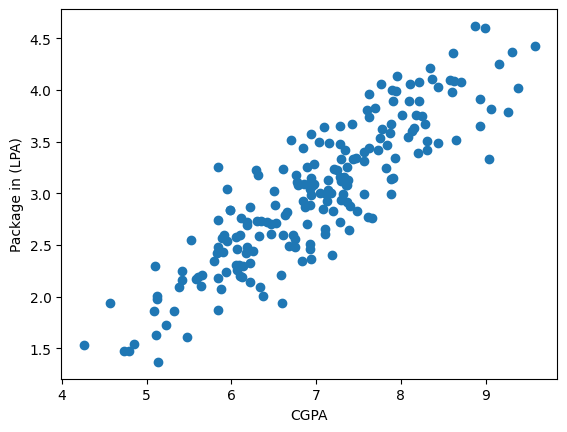

In [31]:
plt.scatter(x=df['cgpa'], y=df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package in (LPA)")

In [32]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [33]:
X.head()

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [36]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
y_pred = lr.predict(X_test)

In [45]:
new_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

new_df['Residual'] = new_df['Actual'] - new_df['Predicted']

print(new_df.head())

     Actual  Predicted  Residual
95     2.79   2.780313  0.009687
15     3.23   3.136352  0.093648
30     3.26   3.199521  0.060479
158    3.04   2.389819  0.650181
128    3.34   3.526847 -0.186847


In [39]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


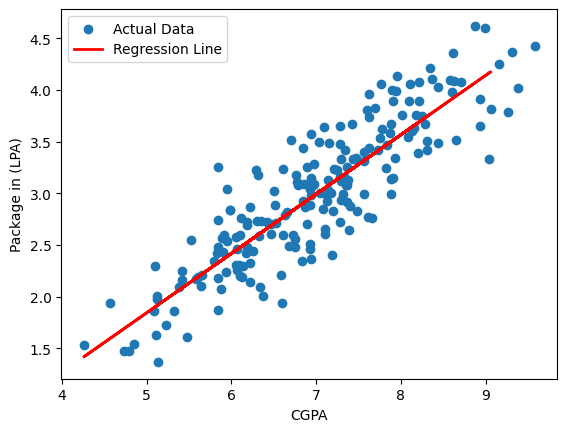

In [40]:
# Plot the actual data points
plt.scatter(x=df['cgpa'], y=df['package'], label='Actual Data')

# Plot the regression line
# X_test usually needs to be the same shape as the input used for training
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("CGPA")
plt.ylabel("Package in (LPA)")
plt.legend()
plt.show()

In [42]:
m = lr.coef_[0]
b = lr.intercept_

print(m, b)

0.5742564727019197 -1.0270069374542108


In [47]:
X_test.head()

,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93


In [48]:
# y = mx + b

m * 6.63 + b

np.float64(2.7803134765595168)